In [62]:
import torch
import torch.nn as nn
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader

In [63]:
# Transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor()
])

In [64]:
import os
import random
import shutil

In [65]:
SOURCE_DIR = "../data/labelled"
TARGET_DIR = "../dataset"

SPLIT_RATIO = 0.8  # 80% train, 20% val

# needed to be this complicated, because on Mac system is looking for a .DS_Store file
classes = [d for d in os.listdir(SOURCE_DIR)
           if os.path.isdir(os.path.join(SOURCE_DIR, d))]

for cls in classes:
    cls_path = os.path.join(SOURCE_DIR, cls)
    images = [f for f in os.listdir(cls_path)
          if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    random.shuffle(images)
    
    split_idx = int(len(images) * SPLIT_RATIO)
    train_images = images[:split_idx]
    val_images = images[split_idx:]
    
    # Create folders
    os.makedirs(os.path.join(TARGET_DIR, "train", cls), exist_ok=True)
    os.makedirs(os.path.join(TARGET_DIR, "val", cls), exist_ok=True)
    
    # Copy files
    for img in train_images:
        shutil.copy(os.path.join(cls_path, img),
                    os.path.join(TARGET_DIR, "train", cls, img))
    
    for img in val_images:
        shutil.copy(os.path.join(cls_path, img),
                    os.path.join(TARGET_DIR, "val", cls, img))

print("Done.")

Done.


In [81]:
# Dataset
train_data = datasets.ImageFolder("../dataset/train", transform=transform)
val_data = datasets.ImageFolder("../dataset/val", transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)


In [82]:
import os
from collections import defaultdict

DATASET_PATH = "../dataset"

summary = defaultdict(dict)

for split in ["train", "val"]:
    split_path = os.path.join(DATASET_PATH, split)
    classes = [d for d in os.listdir(split_path)
               if os.path.isdir(os.path.join(split_path, d))]

    total = 0
    for cls in classes:
        cls_path = os.path.join(split_path, cls)
        count = len([f for f in os.listdir(cls_path)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        summary[split][cls] = count
        total += count

    summary[split]["__total__"] = total

# Print nicely
for split in summary:
    print(f"\n--- {split.upper()} ---")
    for cls, cnt in summary[split].items():
        print(f"{cls}: {cnt}")


--- TRAIN ---
Apistogramma_borelli_opal: 78
Neon_tetra_blue: 34
Sewelia_lineolata: 33
Honey_gourami_natural: 112
Otocinclus_sp: 58
Neocaridina_davidi_yellow: 23
__total__: 338

--- VAL ---
Apistogramma_borelli_opal: 32
Neon_tetra_blue: 17
Sewelia_lineolata: 15
Honey_gourami_natural: 53
Otocinclus_sp: 26
Neocaridina_davidi_yellow: 10
__total__: 153


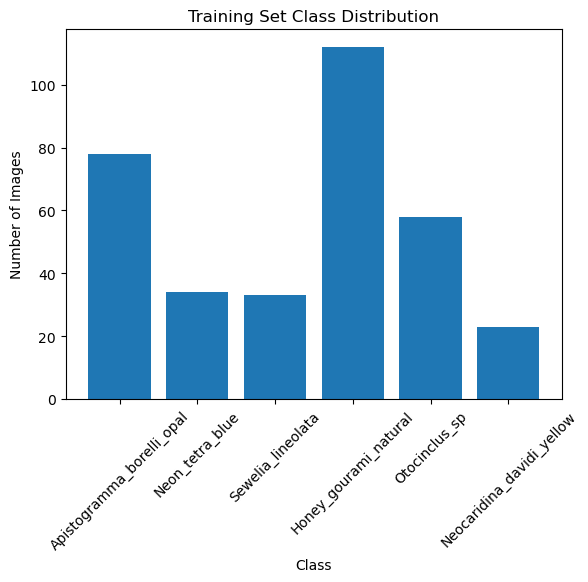

In [83]:
import matplotlib.pyplot as plt

train_counts = {k: v for k, v in summary["train"].items() if k != "__total__"}

plt.figure()
plt.bar(train_counts.keys(), train_counts.values())
plt.xticks(rotation=45)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Training Set Class Distribution")
plt.show()

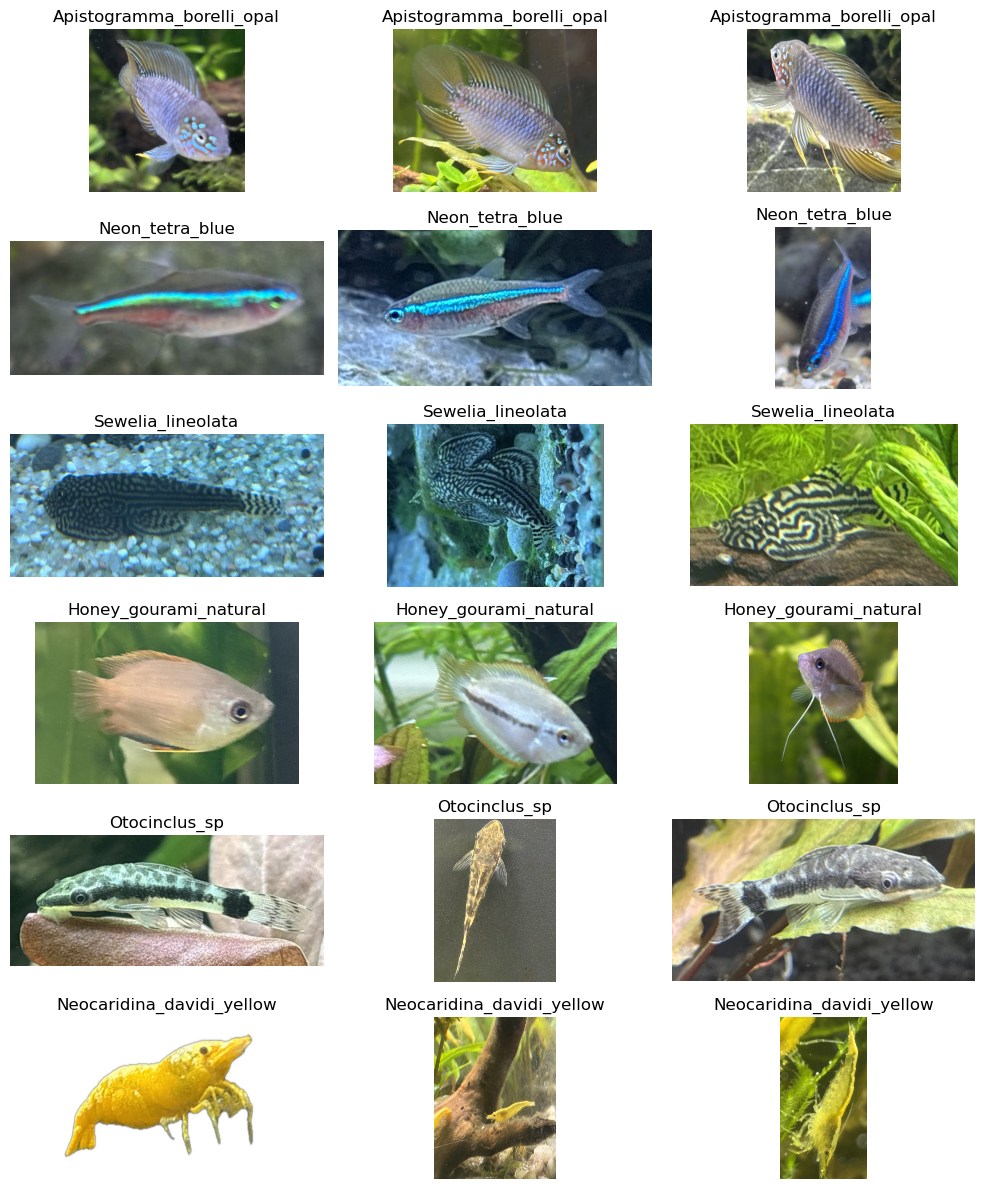

In [84]:
import random
from PIL import Image

def show_samples(dataset_path, split="train", num_samples=3):
    split_path = os.path.join(dataset_path, split)
    classes = [d for d in os.listdir(split_path)
               if os.path.isdir(os.path.join(split_path, d))]

    plt.figure(figsize=(10, len(classes)*2))

    i = 1
    for cls in classes:
        cls_path = os.path.join(split_path, cls)
        images = [f for f in os.listdir(cls_path)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        samples = random.sample(images, min(num_samples, len(images)))

        for img_name in samples:
            img_path = os.path.join(cls_path, img_name)
            img = Image.open(img_path)

            plt.subplot(len(classes), num_samples, i)
            plt.imshow(img)
            plt.title(cls)
            plt.axis("off")
            i += 1

    plt.tight_layout()
    plt.show()

show_samples("../dataset", "train", num_samples=3)

Avg width: 1421.1
Avg height: 1204.8
Min size: 192x162
Max size: 4032x4032


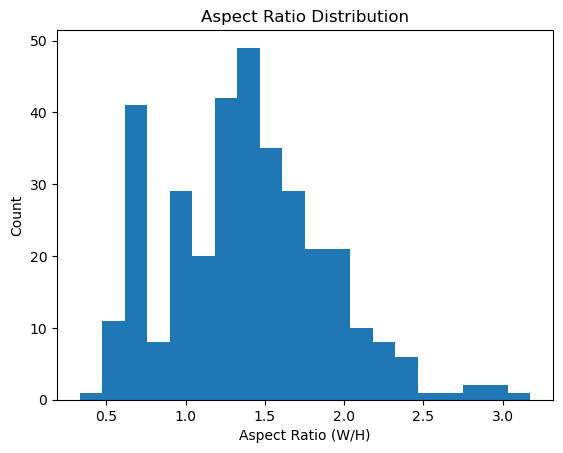

In [85]:
from PIL import Image
import numpy as np

widths = []
heights = []

for split in ["train"]:
    split_path = os.path.join(DATASET_PATH, split)
    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        if not os.path.isdir(cls_path):
            continue

        for f in os.listdir(cls_path):
            if not f.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue

            path = os.path.join(cls_path, f)
            try:
                img = Image.open(path)
                w, h = img.size
                widths.append(w)
                heights.append(h)
            except:
                continue

print(f"Avg width: {np.mean(widths):.1f}")
print(f"Avg height: {np.mean(heights):.1f}")
print(f"Min size: {min(widths)}x{min(heights)}")
print(f"Max size: {max(widths)}x{max(heights)}")

ratios = [w/h for w, h in zip(widths, heights)]

plt.figure()
plt.hist(ratios, bins=20)
plt.xlabel("Aspect Ratio (W/H)")
plt.ylabel("Count")
plt.title("Aspect Ratio Distribution")
plt.show()

In [86]:
# Model
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 6)

/Users/gaborsarosi/miniforge3/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/gaborsarosi/miniforge3/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [87]:
# Freeze backbone
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

In [88]:
# Training setup
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

In [89]:
# For the visualization of training/validation loss/accuracy
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

In [90]:
# Training
import datetime

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")
filename = f"../models/best_model_{timestamp}.pth"

best_val_acc = 0.0
best_epoch = 0

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy


for epoch in range(10):
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    val_loss, val_acc = evaluate(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}:")
    print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.4f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1

        torch.save({
            'epoch': best_epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': best_val_acc,
            'classes': train_data.classes
        }, filename)

        print(f"✅ Best model saved at epoch {best_epoch} with val_acc={best_val_acc:.4f}")

Epoch 1:
  Train Loss: 1.7095, Train Acc: 0.3136
  Val   Loss: 1.4445, Val   Acc: 0.3856
✅ Best model saved at epoch 1 with val_acc=0.3856
Epoch 2:
  Train Loss: 1.2343, Train Acc: 0.6036
  Val   Loss: 1.0665, Val   Acc: 0.7386
✅ Best model saved at epoch 2 with val_acc=0.7386
Epoch 3:
  Train Loss: 0.9546, Train Acc: 0.7722
  Val   Loss: 0.7767, Val   Acc: 0.7908
✅ Best model saved at epoch 3 with val_acc=0.7908
Epoch 4:
  Train Loss: 0.7473, Train Acc: 0.8284
  Val   Loss: 0.5804, Val   Acc: 0.9281
✅ Best model saved at epoch 4 with val_acc=0.9281
Epoch 5:
  Train Loss: 0.6174, Train Acc: 0.8994
  Val   Loss: 0.4781, Val   Acc: 0.9673
✅ Best model saved at epoch 5 with val_acc=0.9673
Epoch 6:
  Train Loss: 0.4949, Train Acc: 0.9290
  Val   Loss: 0.4045, Val   Acc: 0.9673
Epoch 7:
  Train Loss: 0.4043, Train Acc: 0.9586
  Val   Loss: 0.3409, Val   Acc: 0.9739
✅ Best model saved at epoch 7 with val_acc=0.9739
Epoch 8:
  Train Loss: 0.3602, Train Acc: 0.9675
  Val   Loss: 0.2985, Val   

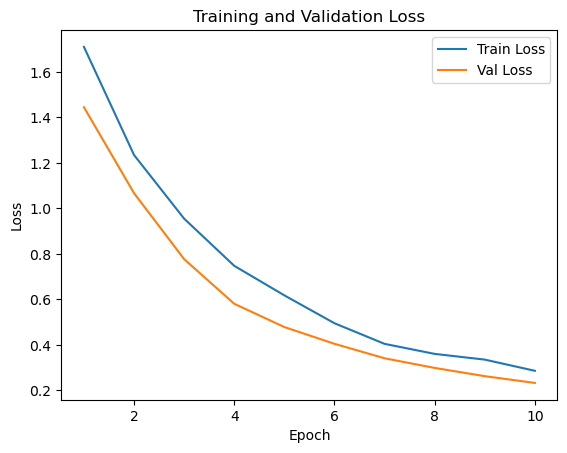

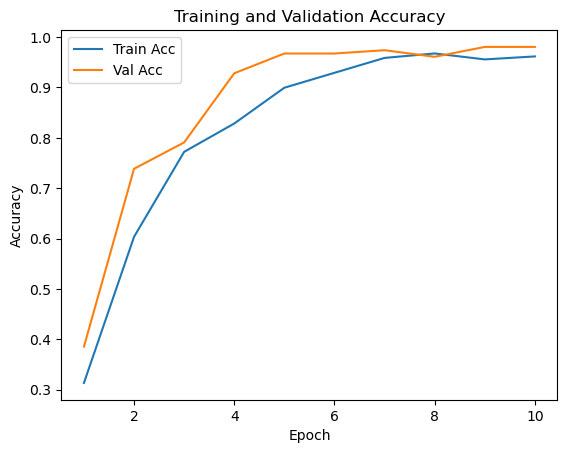

In [91]:
# Visualize the training
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

# Loss plot
plt.figure()
plt.plot(epochs, train_losses)
plt.plot(epochs, val_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend(["Train Loss", "Val Loss"])
plt.show()

# Accuracy plot
plt.figure()
plt.plot(epochs, train_accuracies)
plt.plot(epochs, val_accuracies)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend(["Train Acc", "Val Acc"])
plt.show()

In [92]:
#Collect predictions

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [93]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

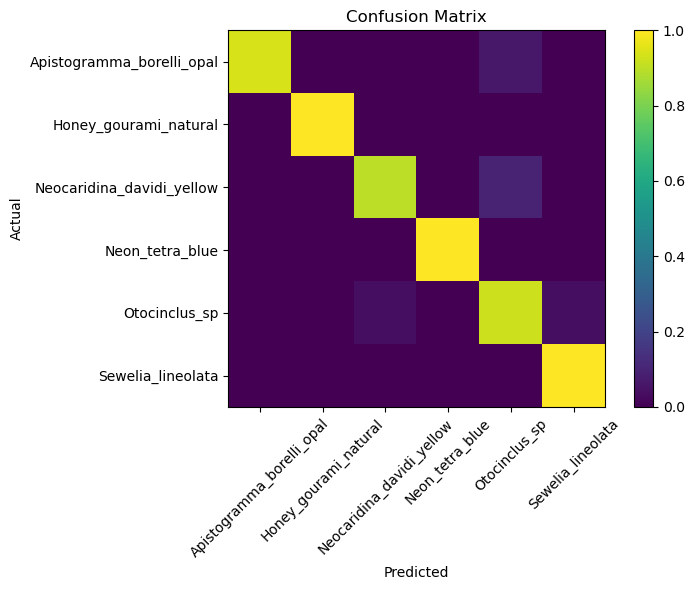

In [94]:
import matplotlib.pyplot as plt
import numpy as np

classes = train_data.classes

plt.figure(figsize=(8, 6))
plt.imshow(cm_normalized, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [95]:
class_accuracy = cm.diagonal() / cm.sum(axis=1)

for i, acc in enumerate(class_accuracy):
    print(f"{classes[i]}: {acc:.2f}")

Apistogramma_borelli_opal: 0.94
Honey_gourami_natural: 1.00
Neocaridina_davidi_yellow: 0.90
Neon_tetra_blue: 1.00
Otocinclus_sp: 0.92
Sewelia_lineolata: 1.00


In [96]:
val_paths = [s[0] for s in val_data.samples]

In [99]:
misclassified = []

for i, (true, pred) in enumerate(zip(all_labels, all_preds)):
    if true != pred:
        misclassified.append((i, true, pred))

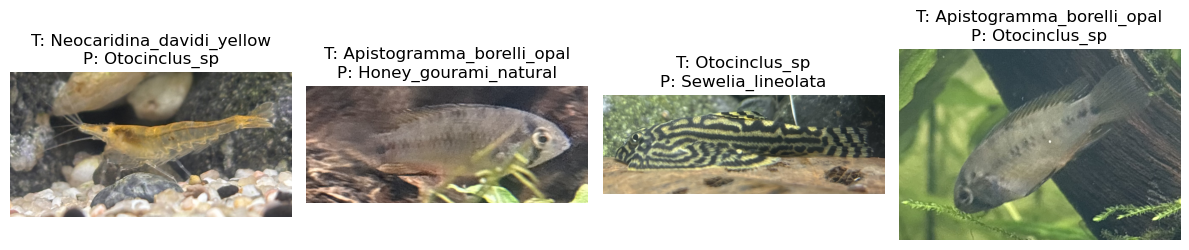

In [100]:
import matplotlib.pyplot as plt
from PIL import Image
import random

classes = train_data.classes

def show_misclassified(num_images=12):
    samples = random.sample(misclassified, min(num_images, len(misclassified)))

    plt.figure(figsize=(12, 8))

    for i, (idx, true, pred) in enumerate(samples):
        img_path = val_paths[idx]
        img = Image.open(img_path)

        plt.subplot(3, 4, i + 1)
        plt.imshow(img)
        plt.title(f"T: {classes[true]}\nP: {classes[pred]}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_misclassified()

In [101]:
from collections import Counter

confusions = Counter()

for true, pred in zip(all_labels, all_preds):
    if true != pred:
        confusions[(true, pred)] += 1

# Sort by most frequent
top_confusions = confusions.most_common(10)

for (true, pred), count in top_confusions:
    print(f"{classes[true]} → {classes[pred]}: {count}")

Apistogramma_borelli_opal → Otocinclus_sp: 1
Apistogramma_borelli_opal → Honey_gourami_natural: 1
Neocaridina_davidi_yellow → Otocinclus_sp: 1
Otocinclus_sp → Sewelia_lineolata: 1


In [103]:
def show_confusion_pair(true_class, pred_class, num_images=6):
    indices = [
        i for i, (t, p) in enumerate(zip(all_labels, all_preds))
        if t == true_class and p == pred_class
    ]

    if not indices:
        print("No samples for this confusion.")
        return

    samples = random.sample(indices, min(num_images, len(indices)))

    plt.figure(figsize=(10, 4))

    for i, idx in enumerate(samples):
        img = Image.open(val_paths[idx])

        plt.subplot(1, num_images, i + 1)
        plt.imshow(img)
        plt.title(f"{classes[true_class]} → {classes[pred_class]}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [105]:
classes

['Apistogramma_borelli_opal',
 'Honey_gourami_natural',
 'Neocaridina_davidi_yellow',
 'Neon_tetra_blue',
 'Otocinclus_sp',
 'Sewelia_lineolata']

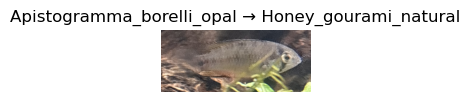

In [107]:
true_idx = classes.index("Apistogramma_borelli_opal")
pred_idx = classes.index("Honey_gourami_natural")

show_confusion_pair(true_idx, pred_idx)

In [109]:
#Error dataset
import os
import shutil

ERROR_DIR = "../errors"
os.makedirs(ERROR_DIR, exist_ok=True)

In [110]:
classes = train_data.classes

for idx, (true, pred) in enumerate(zip(all_labels, all_preds)):
    if true == pred:
        continue

    true_name = classes[true]
    pred_name = classes[pred]

    # Clean folder name (avoid spaces issues)
    folder_name = f"{true_name}__as__{pred_name}".replace(" ", "_")
    folder_path = os.path.join(ERROR_DIR, folder_name)

    os.makedirs(folder_path, exist_ok=True)

    src_path = val_paths[idx]
    filename = os.path.basename(src_path)

    dst_path = os.path.join(folder_path, filename)

    shutil.copy(src_path, dst_path)

In [112]:
# Weighted sampling

hard_paths = set()

for root, dirs, files in os.walk("../errors"):
    for f in files:
        hard_paths.add(os.path.basename(f))  # match by filename

In [113]:
from torch.utils.data import WeightedRandomSampler

weights = []

for path, label in train_data.samples:
    filename = os.path.basename(path)

    if filename in hard_paths:
        weights.append(3.0)  # boost hard samples
    else:
        weights.append(1.0)

In [114]:
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(train_data, batch_size=32, sampler=sampler)